In [ ]:
import polars as pl
import numpy as np
from pathlib import Path
from datetime import datetime as dt
from functools import partial
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import curve_fit

from piepy.psychophysics.wheel.detection.wheelDetectionExperimentHub import WheelDetectionExperimentHub
from piepy.core.data_functions import make_subsets

from piepy.psychophysics.wheel.detection.wheelDetectionGroupedAggregator import WheelDetectionGroupedAggregator
from piepy.plotters.plotting_utils import set_style

from piepy.psychophysics.fit_funcs import mle_fit, neg_likelihood, weibull, erf_psycho

In [ ]:
DATA_PATH = Path.cwd().parents[0] / "260410_Ncomm_inhibition_data.parquet"

CONTRAST_IDX = {0.0:0,
                0.125:1,
                0.5:2}

MANIP_LABEL = {0:"Control",
               1:"Laser ON",}

MANIP_MARKER = {0:"o",
                1:"x",}

STYPE_COLOR = {"0.04cpd_8.0Hz":"#FF7F0F",
               "0.16cpd_0.5Hz":"#0099C2"}

In [3]:
def nan_generator(shape:tuple):
    """_summary_

    Args:
        shape (tuple): _description_

    Returns:
        _type_: _description_
    """
    x = np.zeros(shape)
    x[:] = np.nan
    return x

def sigmoid(x_arr, x0, L, k, p_false=0):
    """
    x0 = x value of the sigmoid midpoint
    L = max value of sigmoid
    k = logistic growth rate aka steepness
    b = y-offset(if needed)
    """
    return L / (1.0 + np.exp(-k * (x_arr - x0))) + p_false

def naka_rushton(c_arr,c50,n,p_max,p_false=0):
    """
    c_arr : contrast array
    n : slope/shape parameter
    c50 : contrast giving halfway point between p_false and p_max
    p_false : probability of saying “yes” when no stimulus is present
    p_max : hit rate at high contrast
    """
    return p_false + (p_max-p_false)/(1+(c50/c_arr)**n)

def fit_naka_rushton(lin_ax, responses, p_false, bounds=None):
    
    fit_func = naka_rushton
    if bounds is None:
        bounds = ([0.5, 1, 0], [1.5, 5, 1]) # [c50,n,p_max]
    
    fit_func_partial = partial(fit_func,p_false=p_false)
    popt,pcov = curve_fit(fit_func_partial, 
                            xdata=lin_ax, 
                            ydata=responses,
                            p0=[1,3,0], 
                            bounds=bounds, 
                            maxfev=100)
    interp_c50 = np.interp(popt[0],lin_ax,[0,12.5,50])
    fitted_p_max = popt[2]
    return popt, interp_c50, fitted_p_max
    
def bootstrap_fit(lin_ax,responses,n_boot=1000):
    
    

    params = np.zeros((n_boot,3))
    params[:] = np.nan
    interp_c50_array = []
    for i in range(n_boot):
        resampled = np.apply_along_axis(np.random.choice,0,responses,size=responses.shape[0],replace=True)
        means = np.nanmean(resampled,axis=0)
        popt,interp_c50,fitted_p_max = fit_naka_rushton(lin_ax,means,p_false=means[0])
        params[i,:] = popt
        interp_c50_array.append(interp_c50)
    return params, interp_c50_array

def bootstrap_means(lin_ax,responses,n_boot=1000):
    
    means = np.zeros((n_boot,3))
    means[:] = np.nan
    interp_c50_array = []
    for i in range(n_boot):
        resampled = np.apply_along_axis(np.random.choice,0,responses,size=responses.shape[0],replace=True)
        means[i,:]=np.nanmean(resampled,axis=0)
        
    return means

In [4]:
hub = WheelDetectionExperimentHub()
# load from session list
# hub.set_data(all_sessions,
#              load_sessions=True,
#              make_summary=True)
# hub.data.write_parquet("250206_experiment_data.parquet")

# load from saved data
all_data = pl.read_parquet("260128_experiment_data.parquet")
hub.set_data(all_data,
             load_sessions=True,
             make_summary=True)

animalid,area,stimulus_count,stim_combination,opto_targets,isTitrated,isCNO,total_trials,stim_type,experiment_count,date,session_ids,stat_total_trial_count,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time
str,str,i32,str,i32,bool,bool,u32,list[str],u32,list[date],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[f64],list[f64],list[f64],list[f64]
"""KC139""","""AL""",1,"""0.04cpd_8.0Hz""",1,false,false,341,"[""0.04cpd_8.0Hz""]",1,[2022-10-18],[5216356],[341],[106],[213],[134],[79],[22],[80],[23.46],[69.925],[39.296],[62.911],[31.085],[37.089],[282.0],[177.6],[0.82294],[69],[98.551],[1.449],[266.0],[166.1]
"""KC139""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,327,"[""0.04cpd_8.0Hz""]",1,[2022-11-08],[4297397],[327],[99],[213],[129],[84],[15],[79],[24.159],[66.418],[39.45],[60.563],[30.275],[39.437],[300.0],[178.6],[0.784455],[65],[90.769],[9.231],[282.0],[163.6]
"""KC139""","""LM""",1,"""0.04cpd_8.0Hz""",1,false,false,849,"[""0.04cpd_8.0Hz""]",1,[2022-11-01],[6503303],[849],[267],[536],[445],[91],[46],[177],[20.848],[95.822],[52.415],[83.022],[31.449],[16.978],[282.0],[171.3],[1.438198],[187],[98.93],[1.07],[249.0],[147.0]
"""KC139""","""PM""",1,"""0.04cpd_8.0Hz""",1,false,false,836,"[""0.04cpd_8.0Hz""]",1,[2022-11-16],[2940665],[836],[331],[463],[369],[94],[42],[155],[18.541],[86.039],[44.139],[79.698],[39.593],[20.302],[299.0],[196.2],[1.094779],[142],[100.0],[0.0],[265.0],[163.8]
"""KC139""","""RL""",1,"""0.04cpd_8.0Hz""",1,false,false,342,"[""0.04cpd_8.0Hz""]",1,[2022-10-25],[3884121],[342],[162],[164],[109],[55],[16],[54],[15.789],[70.909],[31.871],[66.463],[47.368],[33.537],[300.0],[187.9],[0.491155],[50],[96.0],[4.0],[282.0],[171.9]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KC152""","""V1retino""",1,"""0.04cpd_8.0Hz""",2,false,false,512,"[""0.04cpd_8.0Hz""]",1,[2024-08-26],[4243291],[512],[92],[380],[134],[246],[40],[117],[22.852],[41.445],[26.172],[35.263],[17.969],[64.737],[366.0],[251.6],[0.538317],[135],[61.481],[38.519],[350.0],[224.8]
"""KC152""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,674,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",1,[2024-08-18],[4233727],[674],[192],[433],[248],[185],[49],[134],[19.881],[71.237],[36.795],[57.275],[28.487],[42.725],[333.0],[215.6],[0.751814],[151],[92.715],[7.285],[283.0],[182.9]
"""KC152""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,true,550,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2024-08-19],[9727223],[550],[71],[428],[155],[273],[51],[157],[28.545],[52.03],[28.182],[36.215],[12.909],[63.785],[366.0],[256.2],[0.777985],[155],[72.258],[27.742],[349.5],[233.6]


In [5]:
areas = ["LM", "AL", "RL", "PM", "AM"]
stim_combination = "0.04cpd_8.0Hz"
all_data = {}
for a in areas:
    df = hub.filter_by_areas(a,
                        strict_performance=True,
                        stim_combination=stim_combination,
                        isCNO=False)
    
    valid_sesh_ids = []
    for filt_tup in make_subsets(df,["session_id"]):
        filt_df = filt_tup[-1]
        if 1.0 not in filt_df["contrast"].to_list() and 0.0625 not in filt_df["contrast"].to_list():
            print(filt_tup[0],filt_df["contrast"].unique().to_list())
            print(filt_df.filter(pl.col("session_id")==filt_tup[0])[0,"session_path"])
            valid_sesh_ids.append(filt_tup[0]) 
        else:
            pass
        
    
    all_data[a] = df.filter(pl.col("session_id").is_in(valid_sesh_ids))
hub.make_summary_data(df)

3148691 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230216_KC144_detect_opto120_LM__no_cam_KC
3166448 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240823_KC149_detect_opto120_LM__no_cam_KC
5118707 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230912_KC145_detect_opto120_LM__no_cam_KC
5218842 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230117_KC143_detect_opto120_LM__no_cam_KC
5253767 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240814_KC147_detect_opto120_LM__no_cam_KC
6501062 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230110_KC142_detect_opto120_LM__no_cam_KC
6503303 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/221101_KC139_detect_opto120_LM__no_cam_KC
6939780 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240625_KC148_detect_opto120_LM__no_cam_KC
KC148_AL doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
702469 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230117_KC144_dete

animalid,area,stimulus_count,stim_combination,opto_targets,isTitrated,isCNO,total_trials,stim_type,experiment_count,date,session_ids,stat_total_trial_count,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time
str,str,i32,str,i32,bool,bool,u32,list[str],u32,list[date],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[f64],list[f64],list[f64],list[f64]
"""KC139""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,327,"[""0.04cpd_8.0Hz""]",1,[2022-11-08],[4297397],[327],[99],[213],[129],[84],[15],[79],[24.159],[66.418],[39.45],[60.563],[30.275],[39.437],[300.0],[178.6],[0.784455],[65],[90.769],[9.231],[282.0],[163.6]
"""KC142""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,625,"[""0.04cpd_8.0Hz""]",1,[2023-01-12],[3168524],[625],[238],[362],[254],[108],[25],[114],[18.24],[77.419],[40.64],[70.166],[38.08],[29.834],[449.0],[268.6],[0.832561],[126],[93.651],[6.349],[399.5],[220.2]
"""KC143""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,868,"[""0.04cpd_8.0Hz""]",1,[2023-04-05],[1907416],[868],[474],[369],[293],[76],[25],[105],[12.097],[80.682],[33.756],[79.404],[54.608],[20.596],[300.0],[202.0],[0.704756],[127],[96.063],[3.937],[250.0],[174.7]
"""KC144""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,861,"[""0.04cpd_8.0Hz""]",1,[2023-02-21],[6437896],[861],[435],[395],[362],[33],[31],[127],[14.75],[96.269],[42.044],[91.646],[50.523],[8.354],[316.0],[195.2],[1.368537],[130],[99.231],[0.769],[266.0],[166.0]
"""KC147""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,670,"[""0.04cpd_8.0Hz""]",1,[2024-08-26],[5424393],[670],[144],[482],[300],[182],[44],[150],[22.388],[61.446],[44.776],[62.241],[21.493],[37.759],[300.0],[205.1],[1.101248],[154],[82.468],[17.532],[282.0],[184.2]
"""KC148""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,698,"[""0.04cpd_8.0Hz""]",1,[2024-08-25],[2523242],[698],[269],[390],[267],[123],[39],[135],[19.341],[69.02],[38.252],[68.462],[38.539],[31.538],[300.5],[215.3],[0.772012],[108],[95.37],[4.63],[266.0],[177.4]
"""KC149""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,984,"[""0.04cpd_8.0Hz""]",1,[2024-08-25],[9927734],[984],[489],[457],[329],[128],[38],[157],[15.955],[75.0],[33.435],[71.991],[49.695],[28.009],[416.0],[285.0],[0.590219],[154],[82.468],[17.532],[366.0],[233.0]


In [6]:
aggregator = WheelDetectionGroupedAggregator()

area_matrices = {}
for k,v in all_data.items():
    aggregator.set_data(data=v)
    aggregator.group_data(
        group_by=[
            "stim_side",
            "animalid",
            "contrast",
            "opto_pattern",
            "stim_type"
        ]
    )
    aggregator.calculate_hit_rates()
    aggregator.calculate_opto_pvalues()
    
    qq = (aggregator.grouped_data
         .filter((pl.col("contrast") == 0) & (pl.col("opto_pattern") == -1))
         .group_by(["animalid"])
         .agg([
             pl.col("hit_count").sum(),
             pl.col("count").sum()
         ])
    ).sort("animalid")
    catch_trials = qq.with_columns(
        (pl.col("hit_count") / pl.col("count")).alias("baseline_hr")
    )
    
    _data = aggregator.grouped_data.join(
        catch_trials.select(["animalid","baseline_hr"]),
        how="inner",
        left_on= ["animalid"],
        right_on=["animalid"],
    )
    
    plot_data = _data.drop_nulls(["stim_side"]).filter(pl.col("stim_side") != "ipsi")

    
    q = (plot_data.group_by(["contrast","opto_pattern"])
            .agg(
                [pl.col("animalid"),
                 pl.col("hit_rate"),
                 pl.col("count"),
                 pl.col("baseline_hr"),
                 pl.col("median_hit_reaction_times")
                ]
            )).sort("contrast","opto_pattern")
    
    
    data_mat = nan_generator((
        plot_data.n_unique("animalid"),     # 
        plot_data.n_unique("contrast"),     # contrasts
        2,                                  # control, opto
        2                                   # [hit_rate, count]
    ))
    

    for opto_tup in make_subsets(q,["opto_pattern"],start_enumerate=0):
        opto_idx = opto_tup[0]
        opto_df = opto_tup[-1]
        for contrast_tup in make_subsets(opto_df,"contrast",start_enumerate=0):
            contrast = contrast_tup[1]
            contrast_idx = CONTRAST_IDX[contrast]
            contrast_df = contrast_tup[-1]
            
            hr = contrast_df["hit_rate"].explode().to_numpy()
            count = contrast_df["count"].explode().to_numpy()
            
            # b_hr = contrast_df["baseline_hr"].explode().to_numpy()
            
            # if contrast != 0:
            #     #percent_correct, floored at 0
            #     _pc = (hr - b_hr)/np.max(hr-b_hr)
            #     prcnt_corr = np.array([max(i,0) for i in _pc])
            # else:
            #     prcnt_corr = b_hr
            temp = np.hstack((hr.reshape(-1,1),
                                count.reshape(-1,1)))
            data_mat[:,contrast_idx,opto_idx,:] = temp
                                                                
    area_matrices[k] = data_mat
                

 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['early', 'hit', 'miss']


/Users/kaan/miniconda3/envs/piepy/lib/python3.10/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/kaan/code/piepy/piepy/core/statistics.py:54: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap(


 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['miss', 'early', 'hit']
 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['early', 'miss', 'hit']
 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['hit', 'miss', 'early']
 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['early', 'hit', 'miss']


## Plotting



LM Control
avg HR:  [0.19166088 0.66891343 0.85496716]
95CI-: [0.11832837 0.51158167 0.73493646]
95CI+: [0.38754868 0.79896031 0.92798592]


LM Laser ON
avg HR:  [0.16400527 0.35501808 0.83455297]
95CI-: [0.08035714 0.22979252 0.68574935]
95CI+: [0.33650643 0.55245338 0.91682537]


AL Control
avg HR:  [0.20837056 0.70304378 0.92384726]
95CI-: [0.16736441 0.54229756 0.8404584 ]
95CI+: [0.25891909 0.80682369 0.97704521]


AL Laser ON
avg HR:  [0.12982804 0.39601102 0.89983994]
95CI-: [0.0660557  0.30117726 0.82073195]
95CI+: [0.1887982  0.48951886 0.9541546 ]


RL Control
avg HR:  [0.1862208  0.58595617 0.93077144]
95CI-: [0.11847675 0.42939843 0.88083187]
95CI+: [0.24447881 0.71235926 0.97198565]


RL Laser ON
avg HR:  [0.09218143 0.34313199 0.79750836]
95CI-: [0.05967495 0.19567191 0.656702  ]
95CI+: [0.11845922 0.56661036 0.89738121]


PM Control
avg HR:  [0.15136407 0.46858449 0.89292683]
95CI-: [0.10409472 0.32523493 0.79768874]
95CI+: [0.27888326 0.59022069 0.96043872]


PM Laser

/var/folders/jg/zg43p_f517b7tfj20zr4kfrr0000gn/T/ipykernel_99697/3719162196.py:40: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = curve_fit(fit_func_partial,
/var/folders/jg/zg43p_f517b7tfj20zr4kfrr0000gn/T/ipykernel_99697/3719162196.py:40: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = curve_fit(fit_func_partial,
/var/folders/jg/zg43p_f517b7tfj20zr4kfrr0000gn/T/ipykernel_99697/3719162196.py:40: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = curve_fit(fit_func_partial,
/var/folders/jg/zg43p_f517b7tfj20zr4kfrr0000gn/T/ipykernel_99697/3719162196.py:40: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = curve_fit(fit_func_partial,
/var/folders/jg/zg43p_f517b7tfj20zr4kfrr0000gn/T/ipykernel_99697/3719162196.py:40: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov = curve_fit(fit_func_partial,


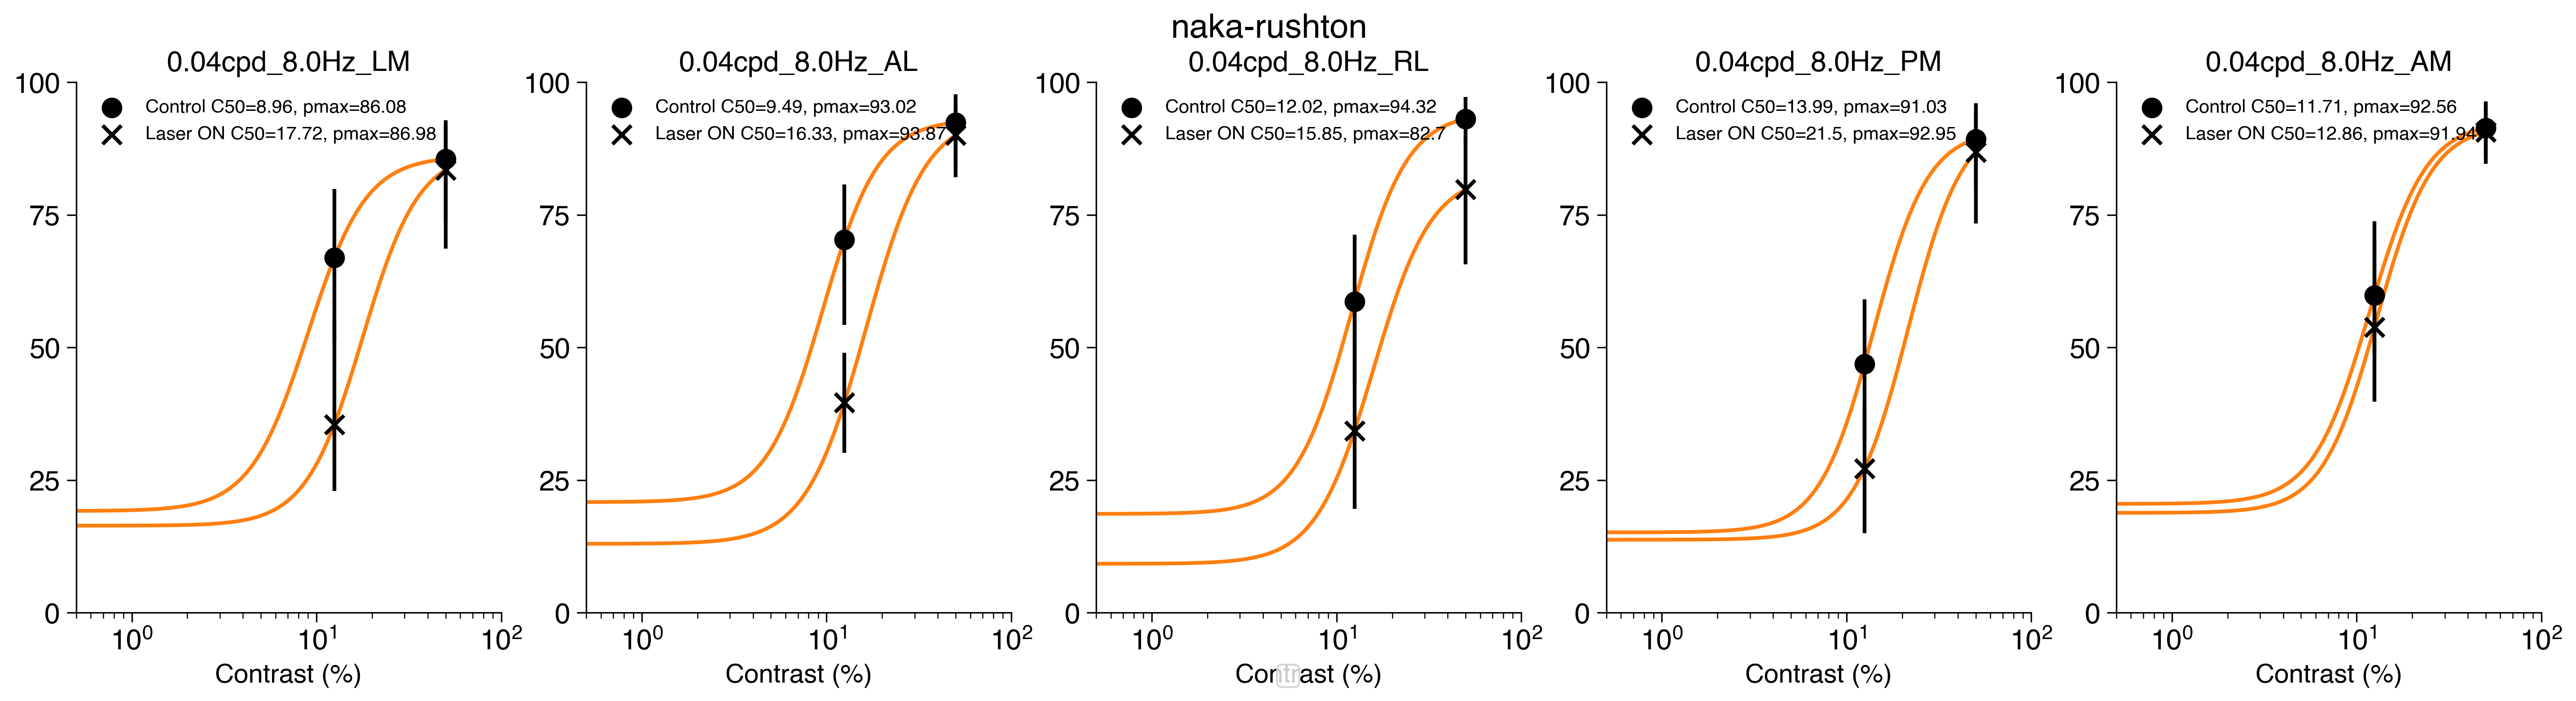

In [8]:
do_fit="naka-rushton"
n_boot = 1000

cm = 1/2.54
set_style("print") 
f,axs = plt.subplots(1,
                     len(area_matrices),
                     figsize=(60*cm,13*cm))

stypes = ["0.04cpd_8.0Hz"]
lin_ax = [0,1,2]
log_ax = [0.1,12.5,50]
do_log=True

xax = log_ax if do_log else lin_ax

custom_handles = []

for area,ax in zip(area_matrices.keys(),axs[:]):
    stype_slice = area_matrices[area]
    
    
    for m_idx in range(stype_slice.shape[2]): 
        manip_slice = stype_slice[:,:,m_idx,0] # use only hr and not count
        
        avg_hr = np.nanmean(manip_slice,axis=0)
        
        # params, interp_c50_array = bootstrap_fit(lin_ax,manip_slice,n_boot=n_boot)
        # means = bootstrap_means(lin_ax,manip_slice,n_boot=n_boot)
        boot_res = stats.bootstrap((manip_slice,),np.nanmean,vectorized=True,n_resamples=1000,paired=True,confidence_level=0.95)
        
        # _fit_data = np.vstack((np.array(lin_ax).reshape(1,-1), 
        #                        counts.reshape(1,-1), 
        #                        hr.reshape(1,-1)))
        # confs = np.percentile(means,[2.5,97.5],axis=0)
        

        popt = [None, None, None]
        interp_c50 = None
        is_fitted = True
        try:                
            if do_fit == "sigmoid":
                fit_func = sigmoid
                bounds = ([0.5, 0, 1], [1.5, 1, 5]) # [x0,L,k]
                fit_func_partial = partial(fit_func,p_false=avg_hr[0])
                popt,pcov = curve_fit(fit_func_partial, 
                                        xax, 
                                        hr, 
                                        p0=[1,0.5,3], 
                                        bounds=bounds, 
                                        maxfev=5000)
                
                interp_c50 = np.interp(popt[0],xax,[0,0.125,0.5])
                fitted_p_max = popt[1]

            elif do_fit == "naka-rushton":
                fit_func = naka_rushton
                bounds = ([1,1,0],[30,3,1])
                popt_avg, interp_c50_avg,fitted_p_max_avg = fit_naka_rushton(xax,avg_hr,p_false=avg_hr[0],bounds=bounds)

                
        except RuntimeError as e:
            is_fitted = False
        
        # jitter = np.random.random(len(lin_ax))*0.01
        # sc = ax.errorbar(lin_ax+jitter,
        #                  hr,
        #                  yerr=(hr+semm,hr-semm),
        #                  color="k",
        #                  linewidth=0,
        #                  elinewidth=1,
        #                  marker=MANIP_MARKER[col_idx],
        #                  label=f"{MANIP_LABEL[col_idx]} C50={round(interp_c50,2)}, pmax={round(fitted_p_max*100,2)}",
        #                  zorder=2,)
        
        # the actual avg dots
        sc = ax.scatter(xax,avg_hr,
                        color="k",
                        label=f"{MANIP_LABEL[m_idx]} C50={round(interp_c50_avg,2)}, pmax={round(fitted_p_max_avg*100,2)}",
                        marker=MANIP_MARKER[m_idx],
                        zorder=2)
        print("\n")
        print(area,MANIP_LABEL[m_idx])
        print("avg HR: ", avg_hr)
        print("95CI-:",boot_res.confidence_interval.low)
        print("95CI+:",boot_res.confidence_interval.high)
        ax.vlines(xax,ymin=boot_res.confidence_interval.low,ymax=boot_res.confidence_interval.high,
                    color="k")
        
        
        
        # fit to 95% CI's
        
        if area == "V1":
            ax.set_ylabel("Hit rate (%)")
        
        if is_fitted:
            x_fit1 = np.linspace(xax[0], xax[1], 50)
            x_fit2 = np.linspace(xax[1], xax[2], 50)
            x_fit = np.concatenate((x_fit1,x_fit2[1:]))
            # x_fit = np.linspace(0, lin_ax[np.argmax(np.abs(lin_ax))], 100)
            # y_fit = weibull(params, x_fit)
            y_fit_avg = fit_func(x_fit, *popt_avg, p_false=avg_hr[0])
            ax.plot(x_fit,y_fit_avg,
                    linewidth=2,
                    color=STYPE_COLOR["0.04cpd_8.0Hz"],
                    zorder=0
                    )
            
            
            # y_fit_upper = fit_func(x_fit,*confs[1,:],p_false=0)
            # y_fit_lower = fit_func(x_fit,*confs[0,:],p_false=0)
            
            # ax.fill_between(x_fit,
            #                 y_fit_avg-y_fit_lower,
            #                 y_fit_avg+y_fit_upper,
            #                 alpha=0.2)
            
            ax.legend(loc="upper left",frameon=False,fontsize=10)
    
    if do_log:
        ax.set_xscale("log")
    ax.set_title(f"0.04cpd_8.0Hz_{area}")
    ax.set_xlabel("Contrast (%)")
    # ax.set_xticks(lin_ax)
    # ax.set_xticklabels([0,12.5,50])
    ax.set_ylim([0,1])
    ax.set_xlim([0.5,100])
    ax.set_yticks([0,0.25,0.5,0.75,1.0])
    ax.set_yticklabels([0,25,50,75,100])
        
        
print(custom_handles)
f.suptitle(f"{do_fit}")
f.legend(handles=custom_handles, ncol=len(MANIP_MARKER),loc='lower center')

In [9]:
savename = f"{do_fit}_ALL_MANIPULATIONS_contrast_response_curves_LOG"
print(savename,"\n")
f.savefig(f"pdf/{dt.strftime(dt.today(),'%y%m%d')}_{savename}.pdf")
f.savefig(f"svg/{dt.strftime(dt.today(),'%y%m%d')}_{savename}.svg")

naka-rushton_ALL_MANIPULATIONS_contrast_response_curves_LOG 

